# Migrating API Test Cases from ReadyAPI to Robot Framework

> *200+ API tests migrated from ReadyAPI to Robot Framework — powered by an LLM loop, validated by layers, humbled by scale.*



<div style="display: flex; justify-content: space-between; align-items: center;">
  <span>📅 02/04/2026</span>
</div>

## Motivation

At my corporate job, I was tasked with migrating over 200 API test cases from ReadyAPI to Robot Framework. While ReadyAPI is an excellent product, it comes with a few drawbacks that motivated the switch:

- **Licensing costs** — ReadyAPI requires a commercial license, which adds up across teams.
- **Bulky application** — The tool is heavy, lacks hot reloading, and limits the kind of customization and hacking you can do with your test suite.

By moving to Robot Framework with Python, we gain a lightweight, open-source, fully version-controlled test suite that's easier to extend and customize.

To tackle the migration of 200+ test cases efficiently, I leaned on AI-assisted coding using [Cursor](https://cursor.com/) — an AI-powered code editor — with models like Anthropic's Claude Opus 4.6 and OpenAI's GPT-5.3-Codex. The reality that LLMs have a limited context window — blow past it and earlier details start getting diluted — shaped how I approached the migration, and I'll share those lessons here.


<center>
<img src="static/blog14/llm_slot_meme.png" width="420" />
</center>

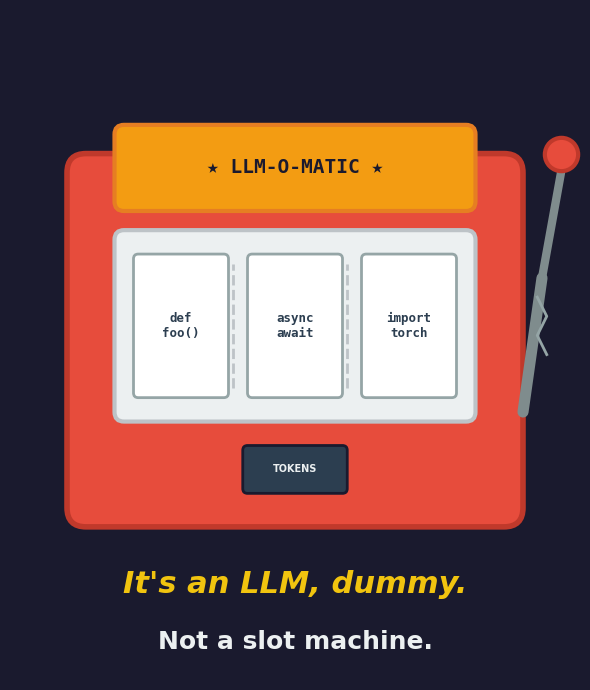

In [ ]:
#| hide
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(6, 7))
ax.set_xlim(0, 6)
ax.set_ylim(0, 7)
ax.axis('off')
fig.patch.set_facecolor('#1a1a2e')

# Slot machine body
body = mpatches.FancyBboxPatch((0.8, 1.8), 4.4, 3.5,
    boxstyle="round,pad=0.2", facecolor='#e74c3c', edgecolor='#c0392b', linewidth=4)
ax.add_patch(body)

# Top of machine
top = mpatches.FancyBboxPatch((1.2, 5.0), 3.6, 0.7,
    boxstyle="round,pad=0.1", facecolor='#f39c12', edgecolor='#e67e22', linewidth=3)
ax.add_patch(top)
ax.text(3.0, 5.35, '★ LLM-O-MATIC ★', ha='center', va='center',
    fontsize=14, fontweight='bold', color='#1a1a2e', fontfamily='monospace')

# Display window
window = mpatches.FancyBboxPatch((1.2, 2.8), 3.6, 1.8,
    boxstyle="round,pad=0.1", facecolor='#ecf0f1', edgecolor='#bdc3c7', linewidth=3)
ax.add_patch(window)

# Three reels with code snippets
reel_texts = ['def\nfoo()', 'async\nawait', 'import\ntorch']
reel_x = [1.8, 3.0, 4.2]
for i, (x, txt) in enumerate(zip(reel_x, reel_texts)):
    reel = mpatches.FancyBboxPatch((x-0.45, 3.0), 0.9, 1.4,
        boxstyle="round,pad=0.05", facecolor='#fff', edgecolor='#95a5a6', linewidth=2)
    ax.add_patch(reel)
    ax.text(x, 3.7, txt, ha='center', va='center', fontsize=9,
        fontfamily='monospace', color='#2c3e50', fontweight='bold')

# Divider lines between reels
for x in [2.35, 3.55]:
    ax.plot([x, x], [3.05, 4.35], color='#bdc3c7', linewidth=2, linestyle='--')

# Lever (pulled / popping)
ax.plot([5.4, 5.6], [2.8, 4.2], color='#7f8c8d', linewidth=8, solid_capstyle='round')
ax.plot([5.6, 5.8], [4.2, 5.3], color='#7f8c8d', linewidth=6, solid_capstyle='round')
ax.plot([5.8], [5.5], 'o', color='#e74c3c', markersize=24, markeredgecolor='#c0392b', markeredgewidth=3)
# Spring effect
ax.plot([5.55, 5.65, 5.55, 5.65], [4.0, 3.8, 3.6, 3.4], color='#95a5a6', linewidth=2)

# Coin slot labeled TOKENS
coin = mpatches.FancyBboxPatch((2.5, 2.0), 1.0, 0.4,
    boxstyle="round,pad=0.05", facecolor='#2c3e50', edgecolor='#1a1a2e', linewidth=2)
ax.add_patch(coin)
ax.text(3.0, 2.2, 'TOKENS', ha='center', va='center', fontsize=7, color='#ecf0f1', fontweight='bold')

# Caption
ax.text(3.0, 1.0, "It's an LLM, dummy.", ha='center', va='center',
    fontsize=22, fontweight='bold', color='#f1c40f', fontfamily='sans-serif', fontstyle='italic')
ax.text(3.0, 0.4, "Not a slot machine.", ha='center', va='center',
    fontsize=18, fontweight='bold', color='#ecf0f1', fontfamily='sans-serif')

plt.tight_layout()
plt.savefig('static/blog14/llm_slot_meme.png', dpi=200, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

## The Core Pattern: Generator-Validator Loop

Before diving into the phases, let me introduce the engine that powered the entire migration: a **generator-validator loop.**

<center>
<img src="static/blog14/DrakeMeme.png" width="420" />
</center>

The idea is simple — use two agents sequentially in the same session:

- **Agent 1 (Generator)** — does the work: analyzes, writes code, produces output.
- **Agent 2 (Validator)** — reviews the generator's output, flags mistakes, suggests improvements.

<center>
<img src="static/blog14/gen_val_loop_final.png" width="420" />
</center>

Once the validator's fixes were applied, I'd loop back to the generator with the same prompt — but framed as *"I've made some changes based on new findings."* This framing is deliberate. By presenting the validator's corrections as external changes, the generator re-evaluates with fresh eyes instead of defending its original output. It helps cancel out the model's [inherent non-deterministic bias](https://tripathysagar.github.io/sagaTrip/llmforwardpass.html).

This pattern was applied at **every phase** of the project — from auto-discovery to code generation to validation. Think of it as the heartbeat of the whole operation.

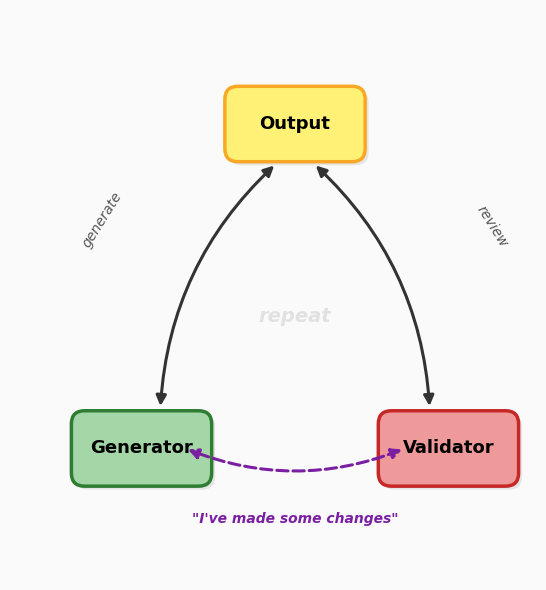

In [ ]:
#| hide
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-1, 5.5)
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')

# Node positions (triangle)
nodes = {
    'Generator':  (1.0, 0.5),
    'Output':     (2.75, 4.2),
    'Validator':  (4.5, 0.5),
}
colors = {'Generator': '#A5D6A7', 'Output': '#FFF176', 'Validator': '#EF9A9A'}
edge_colors = {'Generator': '#2E7D32', 'Output': '#F9A825', 'Validator': '#C62828'}

# Draw shadow + node boxes
for name, (x, y) in nodes.items():
    shadow = mpatches.FancyBboxPatch((x-0.65+0.04, y-0.28-0.04), 1.3, 0.56,
        boxstyle="round,pad=0.15", facecolor='#00000015', edgecolor='none')
    ax.add_patch(shadow)
    box = mpatches.FancyBboxPatch((x-0.65, y-0.28), 1.3, 0.56,
        boxstyle="round,pad=0.15", facecolor=colors[name], edgecolor=edge_colors[name], linewidth=2.5)
    ax.add_patch(box)
    ax.text(x, y, name, ha='center', va='center', fontsize=13, fontweight='bold', fontfamily='sans-serif')

# Double-headed curved arrow helper
def draw_bidir_arrow(start, end, color='#333333', linestyle='-', connectionstyle='arc3,rad=-0.2'):
    dx, dy = end[0]-start[0], end[1]-start[1]
    length = np.sqrt(dx**2 + dy**2)
    shrink = 0.5
    sx = start[0] + shrink * dx/length
    sy = start[1] + shrink * dy/length
    ex = end[0] - shrink * dx/length
    ey = end[1] - shrink * dy/length
    ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
        arrowprops=dict(arrowstyle='<|-|>', color=color, lw=2.2, linestyle=linestyle,
                        connectionstyle=connectionstyle, mutation_scale=15))

# Bidirectional edges curving inward
draw_bidir_arrow(nodes['Generator'], nodes['Output'], connectionstyle='arc3,rad=-0.2')
draw_bidir_arrow(nodes['Output'], nodes['Validator'], connectionstyle='arc3,rad=-0.2')
draw_bidir_arrow(nodes['Validator'], nodes['Generator'], color='#7B1FA2', connectionstyle='arc3,rad=-0.2', linestyle='dashed')

# Labels
ax.text(0.55, 2.8, 'generate', fontsize=10, ha='center', rotation=58, color='#555', fontstyle='italic')
ax.text(5.0, 2.8, 'review', fontsize=10, ha='center', rotation=-58, color='#555', fontstyle='italic')
ax.text(2.75, -0.35, '"I\'ve made some changes"', fontsize=10, ha='center',
        color='#7B1FA2', fontstyle='italic', fontweight='bold')

# Subtle center text
ax.text(2.75, 2.0, 'repeat', fontsize=14, ha='center', va='center', alpha=0.12,
        fontweight='bold', color='#333', fontstyle='italic')

plt.tight_layout()
plt.savefig('static/blog14/gen_val_loop_final.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')

## Phase 1: Auto-Discovery (a.k.a. "What even is all this?")

Before writing a single line of Robot Framework code, I needed to do a brain dump — transfer my understanding of the system, coupled with the actual ground reality, into the agent's head. Think of it as onboarding a new team member, except this one reads at the speed of light and never asks where the coffee machine is.

The ReadyAPI project had a single service with 200+ test cases. Jumping straight into conversion would have been like trying to eat a whole pizza in one bite — ambitious, but messy.

Instead, I pointed the LLM at the ReadyAPI project files and, using the **generator-validator loop**, had it analyze and summarize:

- The overall project structure
- API flows and endpoints
- Test collections and their sizes
- Run environments and configurations
- Data generation setups

The generator would produce findings, the validator would catch gaps or misinterpretations, and the loop would repeat until the picture was complete.

The output? A **markdown file** — the sacred scroll, the single source of truth for the entire migration. Why markdown instead of just keeping everything in the LLM's context? Two reasons:

1. **Context pollution** — LLM conversations are like goldfish memory on a budget. The longer they go, the more earlier details get diluted. A persistent reference file doesn't forget.
2. **Degree of freedom** — any future prompt could point to this file and say "remember this?" instead of re-explaining the entire universe from scratch.

This auto-discovery phase was crucial. It gave me and the LLM a shared map of the territory — because wandering into 200+ test cases without a map is how you end up crying in a corner.

<center>
<img src="static/blog14/Brain.png" width="420" />
</center>

## Phase 2: Inductive Migration (a.k.a. "Start small, scale fast")

With the auto-discovery map in hand, it was time to actually convert test cases. But throwing 200+ cases at the LLM all at once? That's how you get chaos. Instead, I borrowed a page from mathematical induction:

1. **Base case** — a single, simple test case
2. **Small business flow** — a handful of related tests
3. **Smoke tests** → **Sanity tests** → **Full test suite**

At each step, the generator-validator loop did its thing — generate Robot Framework code, validate it, feed corrections back, repeat.

This controlled ramp-up had a key benefit: early on, I could review every line of generated code and catch patterns before they became problems. But as the volume grew and the patterns proved reliable, I made a pragmatic shift — **I stopped reading code and started reading API responses.**

After all, the ultimate test of a test is whether it catches real behavior, not whether it looks pretty. Once the inductive foundation was solid, the LLM had enough established patterns to handle the remaining cases with increasing consistency.

## Phase 3: Kissing the Devil — UI for Self-Supervision

Here's the irony: I was migrating *away* from ReadyAPI, and yet one of the first things I needed was... a UI, in the spirit of Postman/ReadyAPI itself.

As the automation grew in complexity, analyzing raw Robot Framework logs by machine was powerful — but sometimes you just need to *see* things. A dashboard where you can visually inspect what's happening, spot anomalies at a glance, and sanity-check the flow without squinting at terminal output.

So I prompted Cursor to build one using **[FastHTML](https://fastht.ml/)** — a lightweight, Python-native web framework that kept things lean and consistent with the rest of the stack. No heavyweight frontend tooling, no context-switching to a different language — just Python all the way down.

The generator-validator loop handled the UI code just like it handled test code: generate, review, fix, repeat. The result was a clean interface wired into the Robot Framework automation that gave me a self-supervision layer — a human-friendly window into the machine's work. Because no matter how good your automation is, there's no substitute for a pair of eyes that can say *"hmm, that doesn't look right."*

## Phase 4: Delving Deep — Database Validation with Khazad Dum

API responses tell you *what* happened. But to truly validate business logic, you need to see *what changed underneath* — in the database.

The product's relational database was no simple affair. A single API flow could touch **40+ tables**, with data transformations rippling across joins and foreign keys. Manually writing SQL to verify each flow would have been its own full-time job.

This is where [Khazad Dum](https://tripathysagar.github.io/sagaTrip/KhazadDum.html) came in — a Text2SQL agent I had previously built. After each API call, I'd feed it the data generation details and any changes made by the API, and it would fire complex queries across the relevant tables to inspect the actual data flow.

Just like the other phases, the generator-validator loop drove the process: the agent would generate queries, validate the results, and refine until the picture was clear. I also built a **FastHTML UI** for this — a report-style dashboard where I could inspect the database state after each API call, trace data across tables, and verify that the business logic was doing what it was supposed to.

This gave me a **third vantage point** for validation — not just "did the code run?" and "did the API respond correctly?" but "did the data actually land where it should?"

## Phase 5: Embracing the Fuzz — Response Validation Against the Wiki

In any large-scale product, documentation and implementation can drift apart over time. Edge cases get added without updating the wiki, status codes evolve with new conventions (was that a 400 or a 401?), and response strings get tweaked across releases. This is natural — keeping documentation perfectly in sync with a living product is a challenge every team faces.

Building a hardcoded log validator against this documentation would have been brittle — small mismatches between docs and reality would surface as false failures, creating noise rather than signal.

Instead, I took a softer approach. I fed the LLM both the **actual API response** and the **wiki documentation**, and asked it to reason about the gaps. Rather than a binary pass/fail, the LLM could interpret nuance:

- *"The API returned 401 but the wiki specifies 400 — this appears to be a convention update, not a defect."*
- *"This response string differs slightly, but the semantic intent aligns — likely a minor revision not yet reflected in the docs."*

This fuzzy validation layer became yet another vantage point — one that reduced my own **inherent bias** from manual inspection. When you've been deep in the same codebase for weeks, it's easy to see what you expect rather than what's actually there. The LLM, cross-referencing reality against documentation, could surface discrepancies I might overlook.

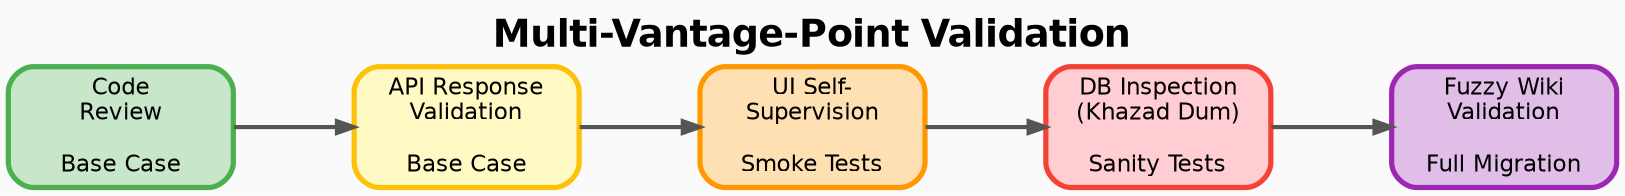

In [ ]:
#| hide
import graphviz
from IPython.display import Image, display

g = graphviz.Digraph('vantage', format='png')
g.attr(rankdir='LR', bgcolor='#FAFAFA', dpi='150', nodesep='0.6', ranksep='0.8')
g.attr('node', shape='box', style='rounded,filled', fontname='Helvetica', fontsize='11', width='1.5', height='0.8')
g.attr('edge', color='#555555', penwidth='2', arrowsize='0.8')

g.node('v1', 'Code\nReview\n\nBase Case', fillcolor='#C8E6C9', color='#4CAF50', penwidth='2.5')
g.node('v2', 'API Response\nValidation\n\nBase Case', fillcolor='#FFF9C4', color='#FFC107', penwidth='2.5')
g.node('v3', 'UI Self-\nSupervision\n\nSmoke Tests', fillcolor='#FFE0B2', color='#FF9800', penwidth='2.5')
g.node('v4', 'DB Inspection\n(Khazad Dum)\n\nSanity Tests', fillcolor='#FFCDD2', color='#F44336', penwidth='2.5')
g.node('v5', 'Fuzzy Wiki\nValidation\n\nFull Migration', fillcolor='#E1BEE7', color='#9C27B0', penwidth='2.5')

g.edge('v1', 'v2')
g.edge('v2', 'v3')
g.edge('v3', 'v4')
g.edge('v4', 'v5')

g.attr(label='Multi-Vantage-Point Validation', labelloc='t', fontsize='18', fontname='Helvetica-Bold')

g.render('static/blog14/vantage_graphviz', cleanup=True)
display(Image('static/blog14/vantage_graphviz.png'))

## Conclusion: Lessons from the Mines

### Work in Progress

This migration isn't a finished story — it's an ongoing one. The 200+ test cases are converted, but validation is never truly "done." There are always more entry points to explore, more edge cases to uncover, more ways to poke at the generated code. The multi-vantage-point approach I've described isn't a checklist you complete — it's a mindset you maintain.

### The Cognitive Load Shift

Early on, I could inspect every line the LLM generated. I knew where everything was, what every function did, and why. But as the automation scaled, that became impossible. The sheer volume of generated code outpaced my ability to review it line by line.

This is the uncomfortable truth of LLM-assisted development: at some point, you have to step back from the code and trust the process. And that's exactly why the multi-vantage-point approach became essential — API response validation, database inspection, fuzzy wiki checks, and UI supervision weren't just nice-to-haves. They were my way of maintaining confidence without needing to read every line. Each vantage point compensated for what I could no longer do manually.

### The Paradox of Control

There's an irony here worth naming: I used LLMs to generate code, then needed *more* LLM-powered tools to supervise that code. Validator agents, Text2SQL inspectors, fuzzy response checkers — each one another layer of AI watching AI. It's turtles all the way down, and it's worth being honest about that.



### Building Trust Incrementally


<center>
<img src="static/blog14/vantage_graphviz.png" width="620" />
</center>

I didn't wire up all the validation at once. The timing was deliberate:

- After **smoke tests** — I built the Postman-style UI so I could run flows myself and visually inspect the results.
- After **sanity tests** — I added database inspection via Khazad Dum to verify data flow.
- After **full migration** — I layered in fuzzy wiki validation for the final sweep.

Each validation layer was introduced when the complexity demanded it, not before.

### Looking Ahead

If I started over tomorrow, I'd question whether the generated code needs to be tied to Robot Framework at all. In the age of LLMs, approaches like **MCP (Model Context Protocol)** or autonomous agents could handle API automation more fluidly — without explicitly coupling to a particular framework's syntax and conventions. The future might not be "migrate test cases from tool A to tool B" but rather "let the agent figure out how to test this."